# EDA 시각화 — LoL 10분 승패 예측

**목적**: 모델을 만들기 전에 데이터가 어떻게 생겼는지 눈으로 확인한다.

| 절 | 그림 | 무엇을 답하나 |
|---|---|---|
| 1 | `eda_corr_top20.png` | 어떤 지표가 승패와 관련 깊은가 |
| 2 | (표) | 같은 정보가 두 번 들어간 컬럼은 없나 |
| 3 | `eda_hist_key_features.png` | 승/패 그룹의 분포가 갈리는가 |
| 4 | `eda1_winrate_curve.png` | 골드차가 실제 승률로 이어지나 |
| 5 | `eda2_effect_size.png` | 무엇이 승패를 가르나 (공정 비교) |
| 6 | `eda3_correlation.png` | 피처를 늘려도 왜 성능이 안 오르나 |
| 7 | `eda4_outliers.png` | 이상치가 있는 컬럼은 |
| 8 | `eda5_game_types.png` | 경기는 몇 가지 유형인가 |

> **모든 분석은 학습셋 7,903경기에서만.** 시험셋 1,976경기는 봉인 상태다.
> EDA에 시험셋을 쓰면 그것을 본 사람의 판단이 모델에 새어 들어간다(누수).

**실행 위치**: 프로젝트 루트에서 실행할 것 (`data/`, `src/`, `reports/` 상대경로 사용)

## 0. 준비

In [1]:
# 경로 자동 설정 — 이 노트북을 어디서 열든 프로젝트 폴더를 찾아 맞춥니다.
# (이게 없으면 data/high_diamond_ranked_10min.csv 를 못 찾는 오류가 납니다)
import os
from pathlib import Path

_p = Path.cwd()
for _ in range(6):
    if (_p / "data").is_dir() and (_p / "predict.py").is_file():
        os.chdir(_p)
        break
    _p = _p.parent
else:
    raise FileNotFoundError("'data' 폴더와 'predict.py' 가 있는 프로젝트 폴더 안에서 열어주세요.")
print("작업 폴더:", os.getcwd())

작업 폴더: C:\AI 캠퍼스 MLOps양성과정\ML\ML실습\4조_LoL 인게임 시점별 경기 데이터 기반 승패 예측 및 핵심 승리요인 분석


In [2]:
import os, sys
import matplotlib, matplotlib.pyplot as plt
import numpy as np, pandas as pd

# 프로젝트 루트로 이동 — notebooks/ 에서 열든 루트에서 열든 같게 동작하게
while not os.path.isdir("data") and os.path.basename(os.getcwd()):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir(parent)
print("작업 위치:", os.getcwd())

# 한글 폰트 — 설정하지 않으면 라벨이 네모로 깨진다
for name in ("Malgun Gothic", "AppleGothic", "NanumGothic"):
    if any(name == f.name for f in matplotlib.font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = name
        break
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지
plt.rcParams["figure.dpi"] = 110

BLUE, RED, GRAY = "#3b6ea5", "#c0504d", "#8c8c8c"
os.makedirs("reports", exist_ok=True)
sys.path.insert(0, "src")
print("폰트:", plt.rcParams["font.family"])

작업 위치: C:\AI 캠퍼스 MLOps양성과정\ML\ML실습\4조_LoL 인게임 시점별 경기 데이터 기반 승패 예측 및 핵심 승리요인 분석
폰트: ['Malgun Gothic']


### 데이터 불러오기

DB 뷰(`v_diff13_train`)를 우선 쓰고, 연결이 안 되면 CSV로 폴백한다.
피처 계산식은 SQL 뷰 한 곳에만 두는 것이 원칙이라 노트북에서 다시 계산하지 않는다.

In [3]:
# 원본(40컬럼) — 상관·중복 검사용
df_raw = pd.read_csv("data/high_diamond_ranked_10min.csv")
tr_idx = pd.read_csv("data/splits/train_idx.csv")["idx"].values
raw = df_raw.loc[tr_idx].drop(columns=["gameId"]).reset_index(drop=True)
y_raw = raw.pop("blueWins")
print(f"원본 학습셋: {raw.shape[0]:,}행 x {raw.shape[1]}피처")

# 차이 피처 13개 — 모델이 실제로 쓰는 재료
try:
    from load_from_db import load
    X, y = load("diff13", "train")
    print("[출처] DB 뷰 v_diff13_train")
except Exception as e:
    print(f"[출처] CSV 폴백 ({type(e).__name__})")
    X = pd.DataFrame({"FirstBlood": raw.blueFirstBlood,
                      "KillsDiff": raw.blueKills - raw.redKills,
                      "GoldDiff": raw.blueGoldDiff,
                      "ExpDiff": raw.blueExperienceDiff})
    for p in ["WardsPlaced", "WardsDestroyed", "Assists", "Dragons", "Heralds",
              "TowersDestroyed", "AvgLevel", "TotalMinionsKilled",
              "TotalJungleMinionsKilled"]:
        X[f"{p}Diff"] = raw[f"blue{p}"] - raw[f"red{p}"]
    y = y_raw
X.shape

원본 학습셋: 7,903행 x 38피처
[출처] CSV 폴백 (RuntimeError)


(7903, 13)

## 1. 정답과의 상관 순위

"어떤 지표가 승패와 관련이 깊은가"의 첫 힌트.
음의 상관(-0.5)도 강한 관계이므로 **절대값 기준**으로 정렬한다.

상위 10:
redGoldDiff           -0.511
blueGoldDiff           0.511
blueExperienceDiff     0.489
redExperienceDiff     -0.489
redTotalGold          -0.420
redGoldPerMin         -0.420
blueGoldPerMin         0.411
blueTotalGold          0.411
blueTotalExperience    0.398
redTotalExperience    -0.385


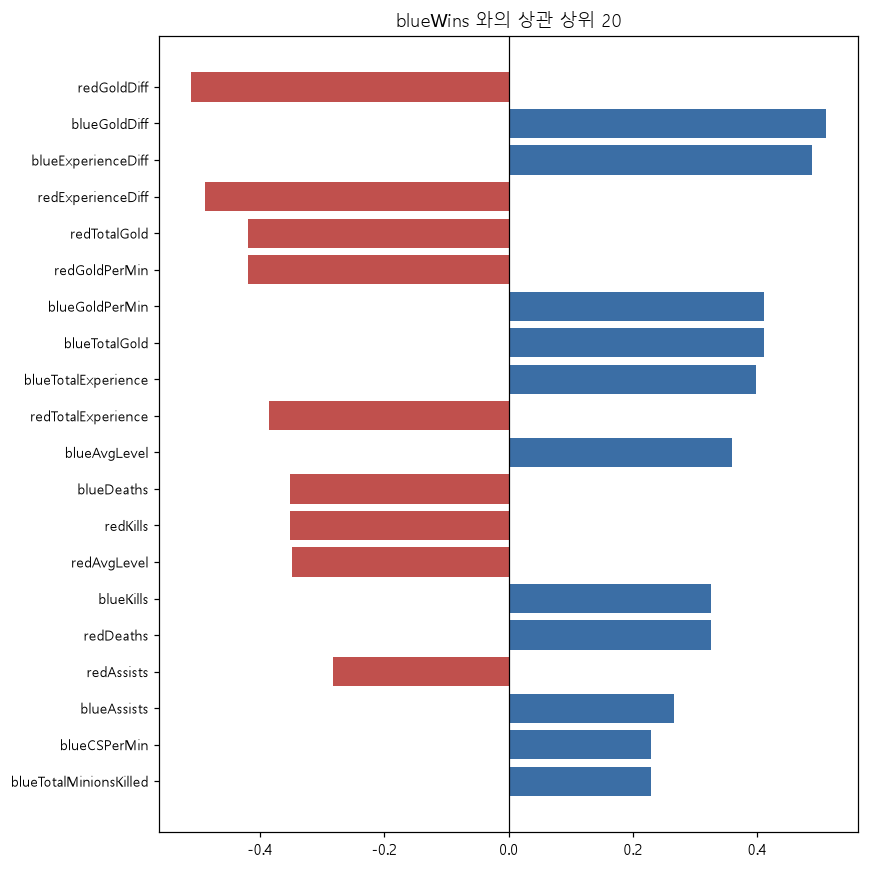

In [4]:
corr = raw.corrwith(y_raw).sort_values(key=abs, ascending=False)
print("상위 10:")
print(corr.head(10).round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 8))
top = corr.head(20)[::-1]                      # [::-1] 큰 값이 위로 오게 뒤집기
ax.barh(range(len(top)), top, color=[BLUE if v > 0 else RED for v in top])
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index, fontsize=9)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("blueWins 와의 상관 상위 20")
fig.tight_layout()
fig.savefig("reports/eda_corr_top20.png")
plt.show()

→ **골드차 0.51 > 경험치차 0.49.** 킬보다 돈이라는 가설의 첫 근거.

## 2. 완전 중복 컬럼 찾기

같은 정보가 두 번 들어가면 중요도 해석이 왜곡된다.
블루/레드 대칭 구조 때문에 생긴다 (예: `blueKills == redDeaths`).

In [5]:
cm = raw.corr()
cols = cm.columns
dup = [(cols[i], cols[j], round(cm.iloc[i, j], 3))
       for i in range(len(cols)) for j in range(i + 1, len(cols))
       if abs(cm.iloc[i, j]) > 0.999]          # 부동소수점 오차 감안
print(f"상관 +-1.0 쌍 {len(dup)}개:")
for p in dup:
    print("  ", p)

상관 +-1.0 쌍 9개:
   ('blueFirstBlood', 'redFirstBlood', np.float64(-1.0))
   ('blueKills', 'redDeaths', np.float64(1.0))
   ('blueDeaths', 'redKills', np.float64(1.0))
   ('blueTotalGold', 'blueGoldPerMin', np.float64(1.0))
   ('blueTotalMinionsKilled', 'blueCSPerMin', np.float64(1.0))
   ('blueGoldDiff', 'redGoldDiff', np.float64(-1.0))
   ('blueExperienceDiff', 'redExperienceDiff', np.float64(-1.0))
   ('redTotalGold', 'redGoldPerMin', np.float64(1.0))
   ('redTotalMinionsKilled', 'redCSPerMin', np.float64(1.0))


> ⚠️ **쌍끼리의 상관만으로는 부족하다.**
> `EliteMonsters = Dragons + Heralds` 처럼 **세 컬럼의 합 관계**는 위 검사에 안 걸린다.
> 실제로 이 중복을 놓쳤다가 나중에 VIF(다중공선성)가 무한대인 것을 보고 발견했다.

In [6]:
for side in ("blue", "red"):
    ok = (df_raw[f"{side}EliteMonsters"]
          == df_raw[f"{side}Dragons"] + df_raw[f"{side}Heralds"]).all()
    print(f"{side}EliteMonsters == {side}Dragons + {side}Heralds : {ok}  (9,879행 전수)")

blueEliteMonsters == blueDragons + blueHeralds : True  (9,879행 전수)
redEliteMonsters == redDragons + redHeralds : True  (9,879행 전수)


## 3. 승/패 그룹의 분포

두 그룹이 **갈릴수록** 예측이 쉽고 **겹칠수록** 어렵다.
겹치는 부분이 곧 모델이 틀리는 경기다.

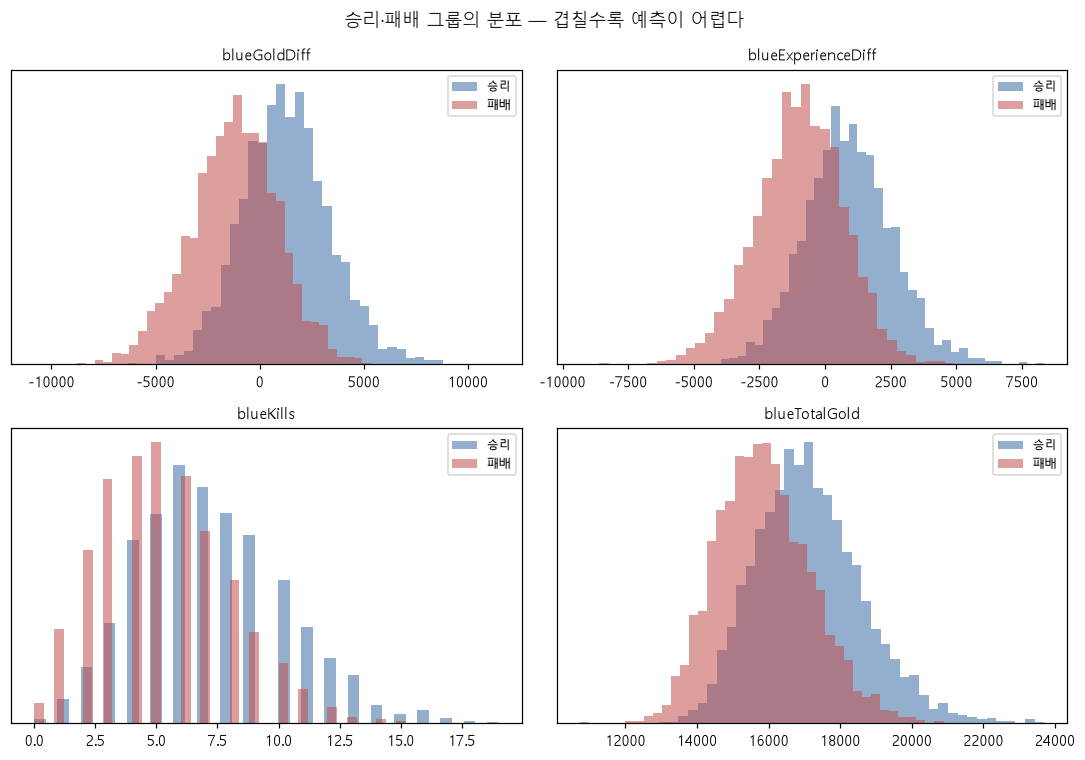

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for a, col in zip(axes.ravel(),
                  ["blueGoldDiff", "blueExperienceDiff", "blueKills", "blueTotalGold"]):
    for v, c, lab in [(1, BLUE, "승리"), (0, RED, "패배")]:
        a.hist(raw.loc[y_raw == v, col], bins=40, alpha=0.55, color=c, label=lab)
    a.set_title(col, fontsize=10)
    a.legend(fontsize=8)
    a.set_yticks([])
fig.suptitle("승리·패배 그룹의 분포 — 겹칠수록 예측이 어렵다", fontsize=12)
fig.tight_layout()
fig.savefig("reports/eda_hist_key_features.png")
plt.show()

## 4. 골드차 구간별 실제 승률

앱의 메인 화면감. 사용자의 현재 위치를 이 곡선 위에 찍어 보여줄 수 있다.

,승률,경기수
GoldDiff,,
-5000\n미만,1.7,181
-5000\n~-2500,13.3,998
-2500\n~-1000,26.8,1462
+-1000\n(팽팽),49.5,2568
1000\n~2500,73.2,1501
2500\n~5000,85.5,1008
5000\n초과,99.5,185


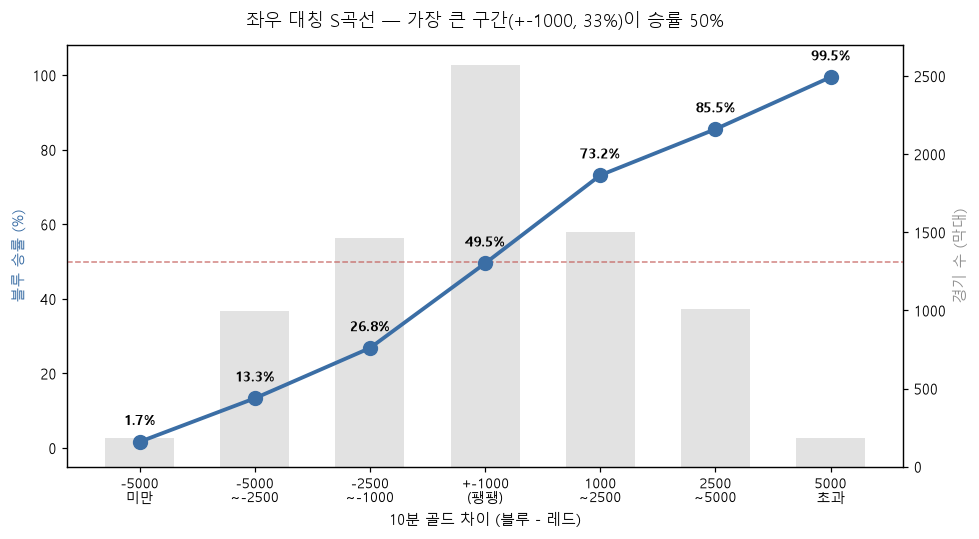

In [8]:
edges = [-np.inf, -5000, -2500, -1000, 1000, 2500, 5000, np.inf]
labels = ["-5000\n미만", "-5000\n~-2500", "-2500\n~-1000", "+-1000\n(팽팽)",
          "1000\n~2500", "2500\n~5000", "5000\n초과"]
b = pd.cut(X["GoldDiff"], bins=edges, labels=labels)
g = pd.DataFrame({"승률": y.groupby(b, observed=False).mean() * 100,
                  "경기수": y.groupby(b, observed=False).size()})
display(g.round(1))

fig, ax = plt.subplots(figsize=(9, 5))
ax2 = ax.twinx()
ax2.bar(range(len(g)), g["경기수"], color=GRAY, alpha=0.25, width=0.6)
ax2.set_ylabel("경기 수 (막대)", color=GRAY)
ax.plot(range(len(g)), g["승률"], "o-", color=BLUE, lw=2.5, ms=9, zorder=5)
for i, v in enumerate(g["승률"]):
    ax.annotate(f"{v:.1f}%", (i, v), textcoords="offset points", xytext=(0, 11),
                ha="center", fontsize=9, fontweight="bold")
ax.axhline(50, color=RED, ls="--", lw=1, alpha=0.7)
ax.set_xticks(range(len(g)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(-5, 108)
ax.set_ylabel("블루 승률 (%)", color=BLUE)
ax.set_xlabel("10분 골드 차이 (블루 - 레드)")
ax.set_title("좌우 대칭 S곡선 — 가장 큰 구간(+-1000, 33%)이 승률 50%", pad=12)
ax.set_zorder(2)
ax.patch.set_visible(False)
fig.tight_layout()
fig.savefig("reports/eda1_winrate_curve.png")
plt.show()

→ **+-1,000 팽팽 구간이 전체의 33%인데 승률 49.7%** — 동전던지기.
여기가 모델이 틀리는 구간이고, 앱에서 신뢰도 낮음 경고를 띄워야 할 지점이다.

## 5. 무엇이 승패를 가르나 — 효과크기

골드(수천 단위)와 킬(한 자릿수)은 단위가 달라 평균 차이를 그대로 비교하면 불공정하다.
**Cohen d** 로 정규화한다.

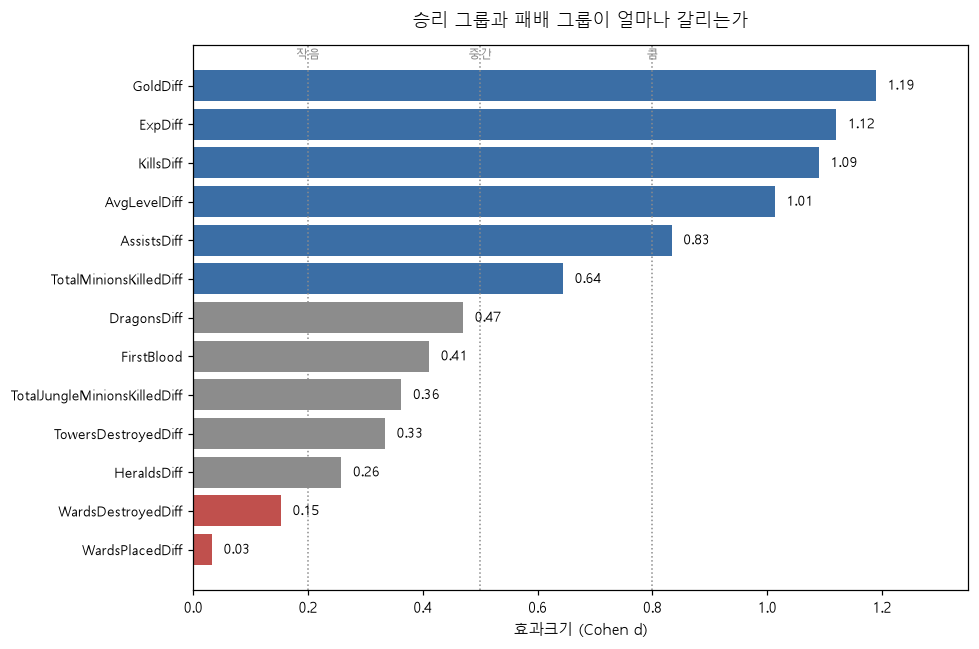

In [9]:
w, l = X[y == 1], X[y == 0]
pooled = np.sqrt((w.var() * (len(w) - 1) + l.var() * (len(l) - 1)) / (len(X) - 2))
d = ((w.mean() - l.mean()) / pooled).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(len(d)), d,
        color=[BLUE if v >= .5 else (GRAY if v >= .2 else RED) for v in d])
for i, v in enumerate(d):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)
ax.set_yticks(range(len(d)))
ax.set_yticklabels(d.index, fontsize=9)
for x0, lab in [(0.2, "작음"), (0.5, "중간"), (0.8, "큼")]:
    ax.axvline(x0, color=GRAY, ls=":", lw=1)
    ax.text(x0, len(d) - 0.3, lab, ha="center", fontsize=8, color=GRAY)
ax.set_xlim(0, 1.35)
ax.set_xlabel("효과크기 (Cohen d)")
ax.set_title("승리 그룹과 패배 그룹이 얼마나 갈리는가", pad=12)
fig.tight_layout()
fig.savefig("reports/eda2_effect_size.png")
plt.show()

→ **와드 설치(0.03)는 사실상 무의미.** 시야를 밝힌 팀이 이긴다는 통념이 성립하지 않는다.

→ **킬(1.09)은 3위로 강력하다.** 로지스틱 계수는 -0.144(음수)로 나오는데 모순이 아니다 —
계수는 골드차를 이미 넣은 뒤 남는 몫이라 뒤집힌 것이다. **앱의 승리요인 화면에는
계수가 아니라 이 효과크기를 써야** 킬하면 진다는 오해가 없다.

## 6. 피처끼리의 관계 — 왜 피처를 늘려도 소용없나

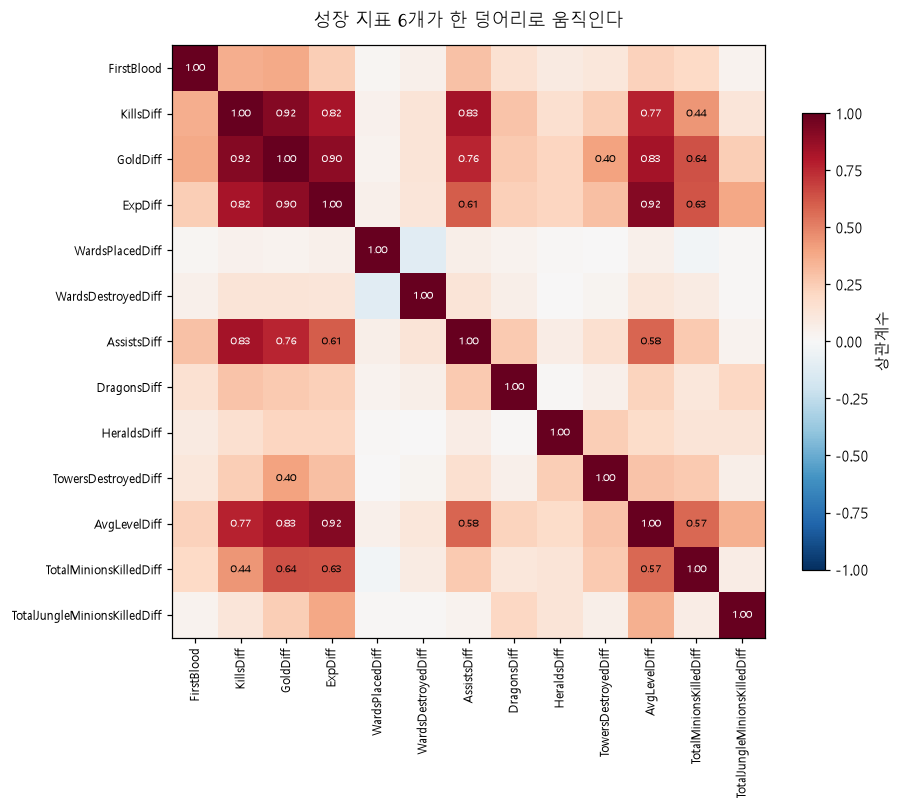

In [10]:
c = X.corr()
fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(c, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(c)))
ax.set_xticklabels(c.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(c)))
ax.set_yticklabels(c.columns, fontsize=8)
for i in range(len(c)):
    for j in range(len(c)):
        v = c.iloc[i, j]
        if abs(v) >= 0.4:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                    color="white" if abs(v) > 0.7 else "black")
fig.colorbar(im, ax=ax, shrink=0.7, label="상관계수")
ax.set_title("성장 지표 6개가 한 덩어리로 움직인다", pad=12)
fig.tight_layout()
fig.savefig("reports/eda3_correlation.png")
plt.show()

→ `GoldDiff` · `ExpDiff` · `KillsDiff` · `AvgLevelDiff` · `AssistsDiff` ·
`TotalMinionsKilledDiff` 여섯 개가 서로 0.42~0.92로 얽혀 있다.
**전부 성장 격차 하나를 다르게 재는 것이다.**
13개처럼 보이지만 담긴 정보는 훨씬 적다 — 그래서 피처 2개가 전체를 이긴다.

## 7. 이상치 진단

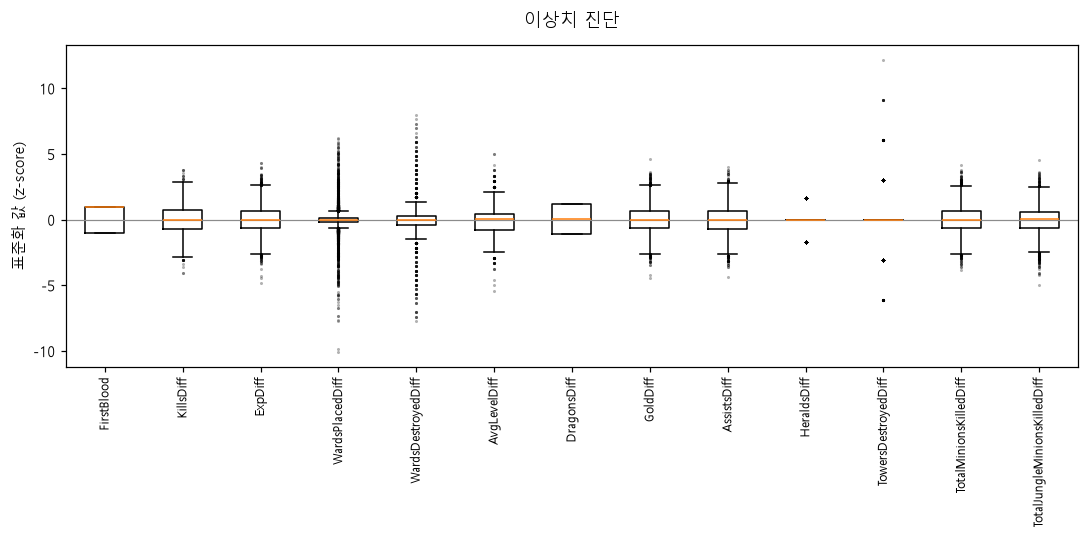

GoldDiff                          1건 ( 0.0%)
ExpDiff                           1건 ( 0.0%)
WardsPlacedDiff                1066건 (13.5%)
WardsDestroyedDiff              165건 ( 2.1%)
AvgLevelDiff                      6건 ( 0.1%)
TotalJungleMinionsKilledDiff      2건 ( 0.0%)


In [11]:
z = (X - X.mean()) / X.std()          # 단위를 맞춰야 한 그림에 놓을 수 있다
order = z.std().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 5))
try:
    ax.boxplot([z[c] for c in order], tick_labels=list(order),
               flierprops=dict(marker=".", markersize=2, alpha=0.3))
except TypeError:                        # matplotlib 3.8 이하 호환
    ax.boxplot([z[c] for c in order], labels=list(order),
               flierprops=dict(marker=".", markersize=2, alpha=0.3))
ax.axhline(0, color=GRAY, lw=0.8)
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.set_ylabel("표준화 값 (z-score)")
ax.set_title("이상치 진단", pad=12)
fig.tight_layout()
fig.savefig("reports/eda4_outliers.png")
plt.show()

for col in X.columns:                    # IQR 3배 밖 비율
    q1, q3 = X[col].quantile([.25, .75])
    iqr = q3 - q1
    if iqr == 0:
        continue
    n = ((X[col] < q1 - 3 * iqr) | (X[col] > q3 + 3 * iqr)).sum()
    if n:
        print(f"{col:30s} {n:4d}건 ({n / len(X) * 100:4.1f}%)")

→ **`WardsPlacedDiff` 만 13.4%.** 25~75%가 +-4에 몰려 있는데 최대는 234다.
효과크기 0.03과 합치면 결론이 분명하다 — **잡음만 크고 신호가 없다.**
다만 군집에서는 유용하다 (와드 120개짜리 시야전 유형을 찾아낸 변수).

## 8. 경기 유형 — 무엇을 어떻게 나눴나

여기부터는 **비지도 학습**이다. 정답(승패)을 쓰지 않고 데이터가 스스로 무리를 짓게 한다.
결과만 보면 이해가 안 되므로 수식을 먼저 정리한다.

### 8-1. 문제: 그냥 군집하면 자명한 결과가 나온다

차이 피처 $x = (\text{GoldDiff}, \text{KillsDiff}, \dots)$ 를 그대로 KMeans에 넣으면
군집이 **"블루 우세 / 레드 우세"** 두 덩어리로 갈린다.
이미 아는 사실(승패)을 되비출 뿐이라 새 정보가 없다.

원인은 **부호**다. 진영을 맞바꾸는 변환을 $\sigma$ 라 하면

$$\sigma(x) = -x$$

이고, $x$ 와 $\sigma(x)$ 는 **같은 성격의 경기**인데 좌표상 정반대에 놓인다.

### 8-2. 해법: 진영에 불변인 좌표로 옮긴다

$\sigma$ 에 대해 값이 변하지 않는 변환 $\phi$ 를 쓴다. 즉

$$\phi(\sigma(x)) = \phi(x)$$

절대값과 양 팀 합이 이 조건을 만족한다. 블루·레드 값을 $b, r$ 이라 하면

$$
\begin{aligned}
g_1 &= \lvert b_{\text{gold}} - r_{\text{gold}} \rvert && \text{일방성 — 얼마나 기울었나 (방향 무시)}\\
g_2 &= b_{\text{kills}} + r_{\text{kills}} && \text{난타전 — 싸움이 얼마나 잦았나}\\
g_3 &= b_{\text{drag}} + b_{\text{her}} + r_{\text{drag}} + r_{\text{her}} && \text{오브젝트 중심이었나}\\
g_4 &= b_{\text{wards}} + r_{\text{wards}} && \text{시야 싸움 강도}\\
g_5 &= b_{\text{cs}} + r_{\text{cs}} && \text{조용히 성장한 경기였나}
\end{aligned}
$$

$b \leftrightarrow r$ 을 바꿔도 $g_1 \dots g_5$ 는 그대로다 → **누가 이기는지가 지워졌다.**

### 8-3. 표준화가 필수인 이유

KMeans는 **유클리드 거리**로 무리를 짓는다.

$$d(a, b) = \sqrt{\sum_{j=1}^{5} (a_j - b_j)^2}$$

$g_1$(골드, 수천 단위)과 $g_2$(킬, 한 자릿수)를 그대로 넣으면
제곱합을 골드가 통째로 지배해 나머지 4개가 무시된다. 그래서 먼저 표준화한다.

$$z_j = \frac{g_j - \mu_j}{\sigma_j} \quad\Longrightarrow\quad \mathbb{E}[z_j] = 0,\ \ \operatorname{Var}(z_j) = 1$$

이제 다섯 축이 같은 발언권을 갖는다.

### 8-4. KMeans가 푸는 문제

$n$ 개 점을 $k$ 개 무리 $S_1, \dots, S_k$ 로 나누되, **무리 안의 흩어짐을 최소화**한다.

$$\arg\min_{S}\ \sum_{i=1}^{k} \sum_{z \in S_i} \lVert z - \mu_i \rVert^2
\qquad \mu_i = \frac{1}{\lvert S_i \rvert} \sum_{z \in S_i} z$$

정확히 풀면 NP-난해라 **Lloyd 알고리즘**으로 두 단계를 번갈아 반복한다.

$$
\begin{aligned}
\text{① 할당}\quad & S_i^{(t)} = \bigl\{\, z : \lVert z - \mu_i^{(t)} \rVert \le \lVert z - \mu_j^{(t)} \rVert \ \ \forall j \,\bigr\} \\[2pt]
\text{② 갱신}\quad & \mu_i^{(t+1)} = \frac{1}{\lvert S_i^{(t)} \rvert} \sum_{z \in S_i^{(t)}} z
\end{aligned}
$$

목적함수가 단조 감소하므로 반드시 수렴하지만 **국소최적**에 빠질 수 있다.
그래서 `n_init=10` 으로 시작점을 10번 바꿔 가장 좋은 것을 고르고, `random_state=42` 로 고정한다.

### 8-5. $k$ 는 어떻게 정했나 — 실루엣

점 $i$ 에 대해

$$a(i) = \text{같은 무리 안 다른 점들과의 평균 거리 (얼마나 뭉쳤나)}$$
$$b(i) = \text{가장 가까운 다른 무리까지의 평균 거리 (얼마나 떨어졌나)}$$

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i),\ b(i)\}} \in [-1, 1]$$

$s$ 가 1에 가까우면 잘 나뉜 것, 0이면 경계에 걸친 것, 음수면 잘못 배정된 것이다.
전체 평균 $\bar{s}$ 로 $k$ 를 비교한다.

> **실측 (5개 중립 피처 기준)**
>
> | $k$ | 2 | 3 | 4 | 5 | 6 |
> |---|---|---|---|---|---|
> | $\bar{s}$ | 0.203 | **0.219** | 0.211 | 0.214 | 0.208 |
>
> **다섯 값이 전부 0.203~0.219 안에 몰려 있다 (폭 0.016).**
> 즉 실루엣은 $k$ 를 **결정해 주지 못한다.** 최고는 $k=3$ 이고 $k=4$ 는 $k=5$ 에도 밀린 3위다.
>
> 그럼에도 **$k=4$ 를 골랐다.** 근거는 점수가 아니라 **해석 가능성**이다 —
> 4개일 때 운영전/난타전/시야전/일방적이라는 이야기가 성립하고, 각 유형에 다른 조언을 붙일 수 있다.
> 지표가 결정을 못 내려 줄 때 **최종 판단은 사람이 한다.**
> (실루엣 값이 낮고 서로 비슷하다는 것 자체가 "이 데이터에 뚜렷이 분리된 덩어리는 없다"는 뜻이다.
> 우리 군집은 자연적 경계를 찾은 것이 아니라 **설명을 위한 구획**에 가깝다 — 발표에서 밝힐 한계다.)

### 8-6. PCA는 무엇을 했나

군집과 별개로, 5차원을 2차원 그림으로 보기 위해 쓴다.
분산이 가장 큰 방향 $w$ 를 찾는 문제다.

$$\max_{\lVert w \rVert = 1} \operatorname{Var}(Zw) = \max_{\lVert w \rVert = 1} w^{\top} \Sigma w
\qquad \Sigma = \frac{1}{n-1} Z^{\top} Z$$

해는 공분산행렬 $\Sigma$ 의 **고유벡터**이고, 설명하는 분산 비율은 고유값 $\lambda_i$ 로

$$\text{설명 분산 비율} = \frac{\lambda_i}{\sum_j \lambda_j}$$

**실측 (중립 피처 5개): $\text{PC1} = 32.0\%$, $\text{PC2} = 20.4\%$, 합 52.4%.**
적재량으로 축의 뜻을 읽으면

| 축 | 주요 적재량 | 해석 |
|---|---|---|
| PC1 | 총킬 **+0.66** / 총CS **−0.65** / 일방성 +0.34 | **교전 ↔ 성장** — 싸울수록 미니언을 덜 먹는다 |
| PC2 | 총와드 **+0.66** / 오브젝트 **−0.57** / 일방성 −0.47 | **시야 ↔ 오브젝트** |

> ⚠️ 다른 문서의 "PC1 37.4% 성장 격차 축 / PC2 12.4% 오브젝트 축"은
> **차이 피처 13개에 PCA를 돌린 별개의 결과**다. 입력이 다르면 축도 다르다. 혼동하지 말 것.

둘을 합쳐도 52.4% 뿐이라 그림은 요약일 뿐이다. 예측에 쓰면 정보 절반을 버리는 셈이다.

### 8-7. 직접 돌려보기

위 수식을 그대로 코드로 옮긴다. (DB의 `gameType` 라벨도 이 계산으로 만든 것)

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 8-2. 사이드 중립 변환 phi — 진영을 바꿔도 값이 안 변한다
G = pd.DataFrame({
    "일방성_골드차": raw.blueGoldDiff.abs(),                                   # g1
    "난타전_총킬":   raw.blueKills + raw.redKills,                             # g2
    "오브젝트_총획득": raw[["blueDragons","blueHeralds",
                            "redDragons","redHeralds"]].sum(axis=1),          # g3
    "시야전_총와드": raw.blueWardsPlaced + raw.redWardsPlaced,                 # g4
    "성장_총CS":     raw.blueTotalMinionsKilled + raw.redTotalMinionsKilled,   # g5
})

# 8-3. 표준화 z = (g - mu) / sigma — 거리 기반이라 필수
Z = StandardScaler().fit_transform(G)
print(f"표준화 확인: 평균 {Z.mean():.2e}, 표준편차 {Z.std():.3f}")

# 8-5. k 별 실루엣 s = (b-a)/max(a,b)
print("\nk별 평균 실루엣:")
for k in range(2, 7):
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z)
    s = silhouette_score(Z, km_k.labels_, sample_size=3000, random_state=42)
    mark = "  <- 최고" if k == 3 else ("  <- 채택 (점수가 아니라 해석 가능성)" if k == 4 else "")
    print(f"  k={k}: {s:.3f}{mark}")

표준화 확인: 평균 1.29e-16, 표준편차 1.000

k별 평균 실루엣:


  k=2: 0.203
  k=3: 0.216  <- 최고


  k=4: 0.207  <- 채택 (점수가 아니라 해석 가능성)


  k=5: 0.215


  k=6: 0.206


In [13]:
# 8-4. KMeans — 무리 안 흩어짐(관성)을 최소화
km = KMeans(n_clusters=4, n_init=10, random_state=42).fit(Z)
print(f"관성(목적함수 값) = {km.inertia_:,.0f}")

# 군집 번호는 실행마다 뒤바뀌므로 '특징'으로 이름을 정한다 (결정적 규칙)
prof = G.groupby(km.labels_).mean()
names, left = {}, list(prof.index)
for label, col in [("일방적경기","일방성_골드차"), ("시야전","시야전_총와드"),
                   ("난타전","난타전_총킬")]:
    c = prof.loc[left, col].idxmax(); names[c] = label; left.remove(c)
names[left[0]] = "운영전"

lab = pd.Series(km.labels_).map(names)
out = G.groupby(lab.values).mean().round(1)
out["경기수"] = lab.value_counts()
out["비중%"] = (lab.value_counts(normalize=True)*100).round(1)
display(out.sort_values("일방성_골드차"))

관성(목적함수 값) = 23,373


,일방성_골드차,난타전_총킬,오브젝트_총획득,시야전_총와드,성장_총CS,경기수,비중%
난타전,1324.0,15.2,0.9,38.7,411.1,2567,32.5
운영전,1366.7,9.2,1.2,40.0,456.3,3263,41.3
시야전,1783.7,12.5,1.2,118.9,428.8,538,6.8
일방적경기,4240.0,14.1,1.2,38.7,425.1,1535,19.4


설명 분산 비율: ['31.8%', '20.5%'] (합 52.3%)

적재량(축의 뜻):


,PC1,PC2
일방성_골드차,0.346,-0.463
난타전_총킬,0.666,0.017
오브젝트_총획득,-0.121,-0.570
시야전_총와드,-0.002,0.667
성장_총CS,-0.649,-0.125


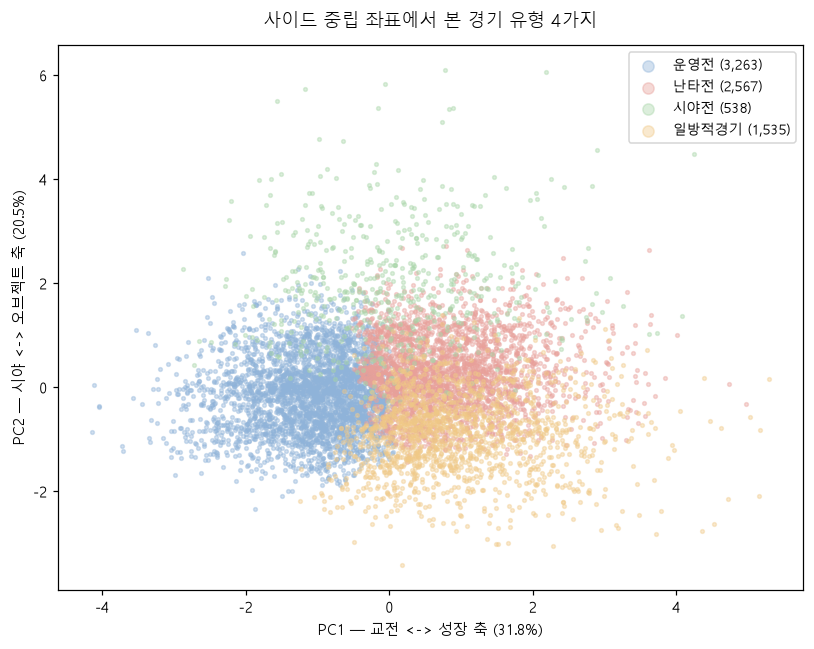

In [14]:
# 8-6. PCA — 5차원을 2차원 그림으로
from sklearn.decomposition import PCA
p = PCA(n_components=2).fit(Z)
print("설명 분산 비율:", [f"{v:.1%}" for v in p.explained_variance_ratio_],
      f"(합 {p.explained_variance_ratio_.sum():.1%})")
print()
print("적재량(축의 뜻):")
display(pd.DataFrame(p.components_[:2].T, index=G.columns,
                     columns=["PC1","PC2"]).round(3))
P = p.transform(Z)

fig, ax = plt.subplots(figsize=(7.5, 6))
pal = {"운영전":"#8fb3d9", "난타전":"#e8a09a", "시야전":"#a8d5a8", "일방적경기":"#f0c987"}
for nm, cl in pal.items():
    m = (lab == nm).values
    ax.scatter(P[m,0], P[m,1], s=6, alpha=0.4, color=cl, label=f"{nm} ({m.sum():,})")
ax.set_xlabel(f"PC1 — 교전 <-> 성장 축 ({p.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 — 시야 <-> 오브젝트 축 ({p.explained_variance_ratio_[1]:.1%})")
ax.legend(markerscale=3, fontsize=9)
ax.set_title("사이드 중립 좌표에서 본 경기 유형 4가지", pad=12)
fig.tight_layout(); fig.savefig("reports/eda6_pca_clusters.png"); plt.show()

### 8-8. DB에 고정된 라벨과 대조 (DB 필요)

In [15]:
Q = """SELECT gameType, COUNT(*) n, AVG(oneSidedGold) 골드차,
              AVG(totalKills) 총킬, AVG(totalWards) 총와드,
              AVG(CASE WHEN (GoldDiff>0)=(y=1) OR GoldDiff=0 THEN 1 ELSE 0 END) 리드팀승률
       FROM lol_analysis_10min WHERE split=%s
       GROUP BY gameType ORDER BY 골드차"""
try:
    import pymysql
    conn = pymysql.connect(host="mis.iptime.org", port=13306, user="pioneer4",
                           password=os.environ["DB_PASSWORD"], database="ABC8pioneer4")
    t = pd.read_sql(Q, conn, params=("train",))
    conn.close()
    display(t.round(2))

    pal = ["#8fb3d9", "#e8a09a", "#a8d5a8", "#f0c987"]
    fig, ax = plt.subplots(1, 3, figsize=(13, 4.5))
    ax[0].pie(t.n, labels=t.gameType, autopct="%1.1f%%", startangle=90, colors=pal)
    ax[0].set_title("경기 유형 비중")
    ax[1].bar(t.gameType, t.골드차, color=pal)
    ax[1].set_title("평균 골드 격차")
    ax[2].bar(t.gameType, t.리드팀승률 * 100, color=pal)
    ax[2].axhline(50, color=GRAY, ls="--", lw=1)
    ax[2].set_ylim(0, 100)
    ax[2].set_title("10분 리드팀의 최종 승률 (%)")
    for i, v in enumerate(t.리드팀승률 * 100):
        ax[2].text(i, v + 2, f"{v:.0f}%", ha="center", fontsize=9, fontweight="bold")
    for a in ax[1:]:
        a.tick_params(axis="x", labelsize=9)
    fig.tight_layout()
    fig.savefig("reports/eda5_game_types.png")
    plt.show()
except Exception as e:
    print(f"건너뜀 (DB 필요): {type(e).__name__} — DB_PASSWORD 설정 후 재실행")

건너뜀 (DB 필요): KeyError — DB_PASSWORD 설정 후 재실행


→ **일방적 경기(19%)는 10분에 이미 결판** (리드팀 승률 90%).
접전인 운영전·난타전(74%)은 68%로 **3판 중 1판이 뒤집힌다.**

---

## 정리

| 발견 | 어디에 쓰나 |
|---|---|
| 골드차가 압도적 1위 | 승리요인 순위표 (FR-2) |
| 성장 지표 6개가 한 덩어리 | 튜닝 여지 없음의 근거 → 2시간 상한 |
| 와드 설치는 무의미 (0.03) | 발표용 반직관적 발견 |
| +-1000 구간 33%가 승률 50% | 앱 신뢰도 경고 (FR-4) |
| 경기 4유형 | 유형별 조언 화면 (FR-5) |

자세한 수치는 `docs/data_analysis.md` 2부(기술통계), 피처 선정 근거는 같은 문서 1부(피처 명세) 참고.